**Lab 6: IIR Filtering**


The objective for this lab is to help you understand the relationship between the location
of poles and zeros in the z-domain, the impulse response h[n] in the n-domain, and the frequency
response $H(e^{j\omega})$. We use the system function,
represented as a ratio of polynomials in $z^{-1}$, which can be expressed in either factored or expanded form as:

$$
H(z) = G\frac{\prod_{k=1}^M (1-z_kz^{-1}) }{\prod_{k=1}^N (1-p_kz^{-1})} = \frac{ \sum_{k=0}^M b_kz^{-k}}{ 1- \sum_{k=1}^N a_kz^{-k} }
$$

In [ ]:
!git clone https://github.com/mench05/sis1_group5.git

import numpy as np
import IPython.display as ipd
from scipy import signal
import matplotlib.pyplot as plt

from util import load_audio, plot_signals, plot_spectrogram, plot_frequency_response

**1. IIR filters to extract the envelope**

In the previous labs, you extracted the envelope from your reference signal by applying the following system:

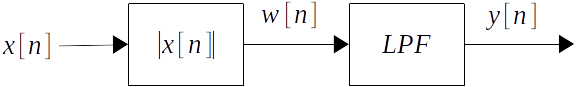

where $w[n] = |x[n]|$ and $y[n]$ was the output of a low-pass FIR filter (averaging filter). In this exercise, you will re-implement this low-pass filter as an IIR.

1.1 First, copy the functions envelope and synthesize from previous work and obtain the same synthesis. 



In [34]:
def envelope(x, N):
    w = np.abs(x)
    b = np.ones(N) / N
    y = np.convolve(w, b, mode='same')

    return y

In [35]:
def synthesize(f0, phi, Ak, t):
    y = 0
    for k in range(1, len(Ak) + 1):
        y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
    return y

1.2 Let's take a look at the following system:

$$
H(z) = G\frac{1+z^{-1}}{1-rz^{-1}} \quad   0<r<1 \quad, G = \frac{1-r}{2}
$$

Note that the coefficients of the filter are the following:

$$
b_0 = 1, \quad b_1 = 1, \quad a_0 = 1, \quad a_1 = -r, \quad
$$

i. Find the zeros and poles of the system analytically.

The analytical process for finding the zeros and poles of the system H(z) begins by rewriting the transfer function to work with positive powers of z. This is achieved by multiplying both the numerator and the denominator by z. The system's zeros are the values of z that set the numerator to zero, meaning z+1 = 0, which results in a single zero at z = -1. Conversely, the poles are the values of z that set the denominator to zero, meaning z-r = 0, which results in a single pole at p = r. Given the system's condition that 0 < r < 1, the pole lies inside the unit circle in the z-plane, confirming that the filter is stable.

ii. Use the function `np.roots` to find the zeros and poles using Python. Compare the results with part i.

In [36]:
# We define r between a value from 0 to 1
r = 0.9
b = np.array([1, 1])     # Numerator: b0=1, b1=1
a = np.array([1, -r])    # Denominator: a0=1, a1=-r

zeros = np.roots(b)
poles = np.roots(a)

print(f"Parameter r: {r}")
print(f"Zeros founded by np.roots (z): {zeros}")
print(f"Poles founded by np.roots (p): {poles}")

Parameter r: 0.9
Zeros founded by np.roots (z): [-1.]
Poles founded by np.roots (p): [0.9]


The comparison of the numerical results with the analytical results from part i confirms the correct system modeling. The zero obtained using np.roots is z = -1, and the pole is p = r, which validates the values obtained analytically.

iii. Use the function  `plot_zeros_poles(z, p)` to plot the zeros and poles found in ii.

In [37]:

from util import plot_zeros_poles 
plot_zeros_poles(zeros, poles)

1.3 Let's see the frequency response of this filter:



In [38]:
from scipy import signal

r = 0.9
G = (1-r)/2

b = np.array([1,1]) 
a = np.array([1, -r])   

w = np.linspace(-np.pi,np.pi, 800)
ejw = np.exp(-1j * w)
H = G * (b[0] + b[1] * ejw) / (a[0] + a[1] * ejw)

plot_frequency_response(w,H)

1.4. Change the parameter $r$ in the range $(0, 1)$. What happens when $r$ is increased?

When you increase the value of the parameter r (bringing it closer to 1), the filter's pole moves very close to the z = 1 position. Since the z = 1 position represents zero frequency (the lowest frequency), this greatly amplifies that area.

1.5 What type of filter is (low-pass, band-pass, or high-pass filter)?


The filter is a low-pass filter. We know this because its zero is at z = -1, which completely annihilates the high frequencies (ω = π). At the same time, the pole is at p = r, very close to z=1, which amplifies the low frequencies (ω = 0). Since the filter allows low frequencies to pass and blocks high frequencies, it is classified as low-pass.

1.6 Now we can use this IIR filter to extract the envelope. Let's define a new function `envelope_iir(x)` that applies the filter to the absolute value of the signal. Note that we are using signal.lfilter function to apply the filter.


In [39]:
def envelope_iir(x, r=0.9):
    w = np.abs(x)
    b = np.array([1, 1])
    a = np.array([1, -r])
    G = (1 - r) / 2
    y = signal.lfilter(b, a, w)
    return G * y


Extract the envelope of your reference signal using both the FIR and IIR filters and compare the results plot them along with the signal. Change the value of $r$ until you are comfortable with the result.

In [ ]:
x_ref, fs = load_audio("sis1_group5/labs/audio/audio.wav")

r = 0.9

env_fir = envelope(x_ref, 100)
env_iir = envelope_iir(x_ref, r)


plot_signals([x_ref,env_iir, env_fir], fs, name=['Signal Ref', 'Enveloped IIR', 'Enveloped FIR'], mode='lines')

1.7 What are the main differences between the two filters? For instance, compare the number of coefficients.

The FIR filter uses many coefficients (like 100) and has very short memory, so its envelope is more rigid and reacts faster.  

The IIR filter only uses 3 coefficients and, thanks to the pole r, has long memory and gives a much smoother envelope.

The FIR is more local, while the IIR is smoother and far more efficient.  

For a realistic envelope, the IIR clearly works better.


1.8 Apply the new envelope (extracted from the IIR filter) to the synthesis generated with the `synthesize` function and listen to the result.

In [41]:
f0 = 174.614
phi = np.pi/2
Ak = np.ones(10)

env = envelope_iir(x_ref, r)
env = env / np.max(env)

t = np.arange(len(env)) / fs
y_syn = synthesize(f0, phi, Ak, t)

y_out = env * y_syn
ipd.Audio(y_out, rate=fs)


---

**2. Band-pass filters**

Now let's work with the following system: 

$$
H(z) = \frac{(1-z^{-1})(1+z^{-1})}{(1-re^{j\omega_n}z^{-1})(1-re^{-j\omega_n}z^{-1})}, \quad 0<r<1
$$

Note that the poles are $p_1 = re^{j\omega_n}$ and $p_2 = re^{-j\omega_n}$; and the zeros are $z_1=1$ and $z_2=-1$. 

2.1 Use the function `plot_zeros_poles` to plot the zeros and poles of the system.

Note: use $w_n = \pi/4$ and $r=0.99$.

In [42]:
w_n = np.pi/4
r = 0.99

zeros = np.array([1, -1])
poles = np.array([r * np.exp(1j * w_n), r * np.exp(-1j * w_n)])

plot_zeros_poles(zeros, poles)


2.2 Show analytically that $a_k = [1, -2rcos(\omega_n), r^2]$ and $b_k=[1, 0, -1]$.

## Obtaining the Filter Coefficients

To obtain the filter coefficients, we expand the numerator and denominator of the system.

---

### **Numerator**

$(1 - z^{-1})(1 + z^{-1}) = 1 - z^{-2}.$

So, the numerator coefficients are:

$ b_k = [1,\, 0,\, -1]. $

---

### **Denominator**

$(1 - r e^{j\omega_n} z^{-1})(1 - r e^{-j\omega_n} z^{-1})$

Multiplying:

$1 - r(e^{j\omega_n} + e^{-j\omega_n})z^{-1} + r^2 z^{-2}.$

Using the identity:

$e^{j\omega_n} + e^{-j\omega_n} = 2\cos(\omega_n)$

we obtain:

$ a_k = [1,\; -2r\cos(\omega_n),\; r^2]. $


2.3 Plot the frequency response of the filter. Confirm this is a band-pass filter. What's the central frequency of the passband?

In [43]:
w = np.linspace(-np.pi, np.pi, 800)
wn = np.pi / 4
z = np.exp(1j*w)

num = 1 - z**(-2)
den = 1 - 2*r*np.cos(wn)*z**(-1) + r**2 * z**(-2)
H = num / den
plot_frequency_response(w, H)

We can see clearly that it's a pass-band filter, and we have two symettric peaks, on each side of 0, therefore the central frequency of pass-band is when wc=wn, we know that wn is defined as pi/4

2.4 Define a function `bpf(x, f, r, fs)` that applies the above band-pass filter. 

Note 1: remember that a frequency can be converted to the normalized radian frequncy by: $\omega_n = 2\pi f_n/f_s$.

Note 2: use `signal.lfilter` function to implement the filter.

In [44]:
def bpf(x, fn, fs, r=0.995):
    w_n = 2 * np.pi * fn / fs
    b = np.array([1, 0, -1])
    a = np.array([1, -2 * r * np.cos(w_n), r**2])
    return signal.lfilter(b, a, x)


2.5 Regardless of the phase, until now we were synthesizing the instrument signal by summing $K$ harmonics of the signal with different weights ($A_k$) and multiplying the sum by the envelope of the reference signal ($e(t)$):

$$y(t) = e(t) \cdot \sum_{k=1}^K A_k\cos\left(2\pi kf_0 t \right), $$

where $f_0$ is the fundamental frequency of the note. Now we want to improve this synthesis by finding a time-dependent amplitude ($A_k(t)$) for each harmonic:

$$y(t) = \sum_{k=1}^K A_k(t) \cos\left(2\pi kf_0 t \right), $$

where $A_k(t)$ is the amplitude of the harmonic $k$. To extract the amplitudes $A_k(t)$ we'll apply a band-pass filter with central frequency $kf_0$ and calculate the envelope of the output by using the `envelope_iir`.


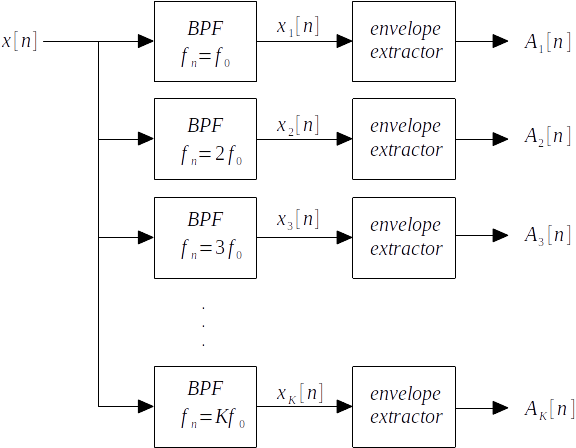

For instance, the following code should extract the envelope of the fundamental frequency component. Change the value of $f_0$ to coincide with your fundamental frequency and check the result. 

In [ ]:
f0 = 174.614

x_fund = bpf(x_ref, f0, fs)
A1_t = envelope_iir(x_fund, r)

plot_signals([x_fund, A1_t], fs, name=["Fundamental X", "Env. A1(t)"])


2.6 Complete the `synthetize_with_bpf` function to implement a synthesis applying different envelopes for each harmonic.


In [46]:
def synthetize_with_bpf(x, f0, phi, K, fs):
    L = len(x)
    t = np.arange(L) / fs
    y = np.zeros(L)

    for k in range(1, K + 1):
        xk = bpf(x, k * f0, fs)
        Ak_t = envelope_iir(xk)
        Ak_t = Ak_t / np.max(Ak_t)
        y += Ak_t * np.cos(2 * np.pi * k * f0 * t + k * phi)

    return y


2.6 Call the function `synthetize_with_bpf` to get the synthesized signal and **listen to it**.

Note that now you can increase the number of harmonics $K$ as you want because we are not manually measuring the weights of each harmonic.

In [55]:
y_bpf = synthetize_with_bpf(x_ref, f0, phi, K=10, fs=fs)
ipd.Audio(y_bpf, rate=fs)


2.7 Compare the **spectrograms** of the synthesized signal and reference signal.

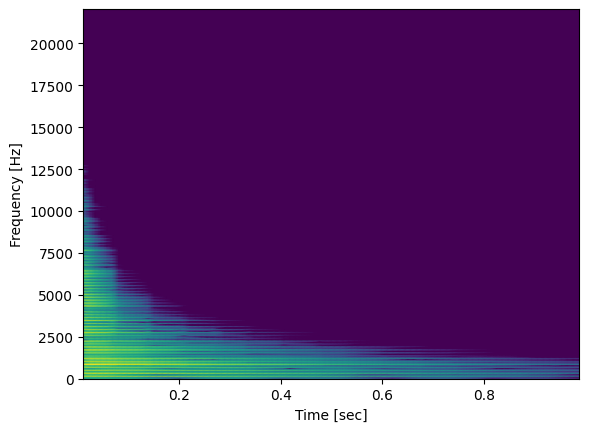

In [56]:
ff, tt, ref = signal.spectrogram(x_ref, fs, nperseg=1024, noverlap=512)
ff_synth, tt_synth, synth = signal.spectrogram(y_bpf, fs, nperseg=1024, noverlap=512)


plot_spectrogram(ff,tt, ref)

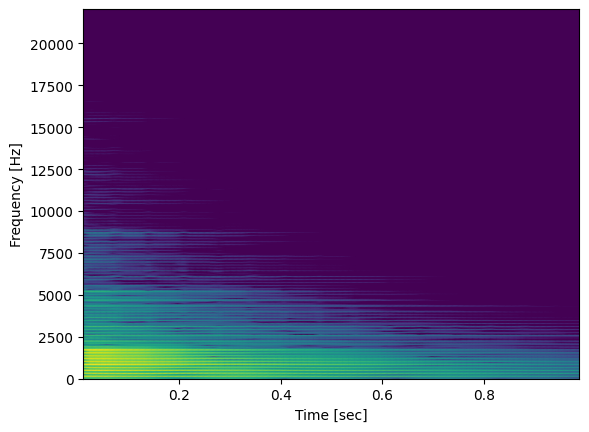

In [58]:
plot_spectrogram(ff_synth,tt_synth, synth)

The second spectogram seems more filtered and clean, and more concetrated in the low frequencies, while the first one, is more richer in high frequencies and less cushioned.